In [3]:
from Pub_plots import *

In [4]:
# prepare dataset
import utils.Config as Config
import tensorflow as tf
import utils.gestureDataLoader as gestureDataLoader
from sklearn.model_selection import train_test_split
from ATKMethods import *
gpus = tf.config.experimental.list_physical_devices( 'GPU' )
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth( gpu, True )
    except RuntimeError as e:
        print( e )
config = Config.getconfig( )
config.source = 'lab_276'
tf.config.experimental_run_functions_eagerly(True)
assert config.source != None, 'source should not be None'
train_data, test_data, train_label, test_label = gestureDataLoader.getData(
        config, 'signfi'
        )
X_train, X_test, y_train, y_test = train_test_split( train_data, train_label, test_size=0.1, random_state=42)
batch_size = config.batch_size
# load model
path = 'Surrogate_model_lab.h5'  
net = AlexNetTF( config )
model = net.buildModel( choice = 'defult')
model.load_weights(os.path.join('SavedModel/Adversarial_robust_model',path))
# model.summary()


Instructions for updating:
Use `tf.config.run_functions_eagerly` instead of the experimental version.
Loading data................


2023-02-15 20:56:46.345029: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-02-15 20:56:46.345745: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-02-15 20:56:46.345914: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-02-15 20:56:46.345972: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so retur

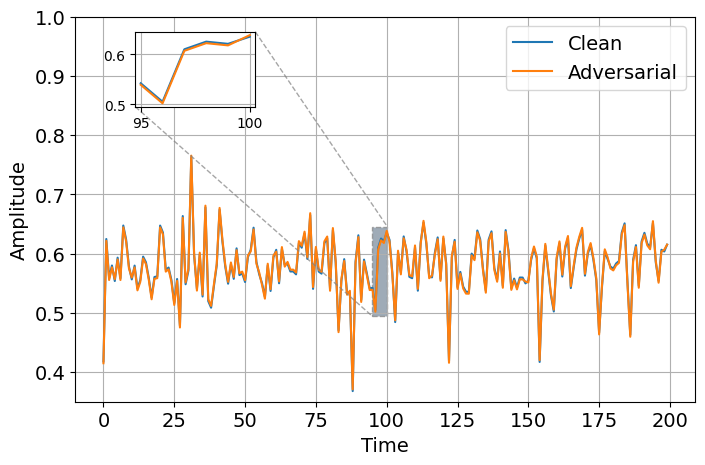

In [6]:
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
delta = gen_adv_data(x = test_data[0:1],
                    y = test_label[0:1],
                    model = model,
                    atk_type = 'fgsm',
                    psr = 0.0001,
                    targeted = False,
                    
                    )
# plt.plot(test_data[0,:,5,0])
adv = test_data[0:1] + delta
# plt.plot(adv[0,:,5,0])
fsize = 14
fig, ax = plt.subplots(figsize=(8, 5))


ax.plot(test_data[0,:,5,0], label = 'Clean')
ax.plot(adv[0,:,5,0], label = 'Adversarial')
ax.legend(fontsize = fsize)
# set ticks size
ax.tick_params(axis='both', which='major', labelsize=fsize)
x_de = np.linspace(95, 100, 6).astype(int)
y_de = adv[0,:,5,0][x_de]

sub_axes = plt.axes([.2, .7, .15, .15]) 

# plot the zoomed portion
sub_axes.plot(x_de, test_data[0,:,5,0][x_de],) 
sub_axes.plot(x_de, adv[0,:,5,0][x_de],) 
#set the x and y limit
ax.set_ylim(0.35, 1)
#set the x and y label
ax.set_xlabel('Time', fontsize = fsize)
ax.set_ylabel('Amplitude', fontsize = fsize)
mark_inset(ax, sub_axes, loc1=3, loc2=1, fc="lightslategrey", ec='0.5', alpha = 0.7,ls = '--')
ax.grid()
# plt.figure( figsize = (8, 5) )

# plt.xticks( fontsize=fsize )
# plt.yticks( fontsize=fsize )
plt.grid()
plt.savefig('RESULTS_FIGS/compare_wave_form.pdf', bbox_inches='tight')
plt.show()
#save to pdf
# out = 
# plt.savefig( out + '.pdf',bbox_inches='tight',  )


#### compare_deepfool_PGD_FGSM.pdf

In [ ]:
'''Plots the FGSM vs DeepFool vs PGD vs Gaussian noise'''
plot(
        # pdf_name = 'compare_deepfool_PGD_FGSM',
        pdf_name = None,
        label_dict = {
                'Deepfool': 'Deepfool',
                'FGSM': 'FGSM',
                'PGD_1': 'PGD (1 iteration)',
                'PGD_2': 'PGD (2 iterations)',
                'PGD_3': 'PGD (3 iterations)',
                'Guassian_Noise': 'Guassian Noise'
                },
        linestyle_dict = { 'FGSM': '--', 'Deepfool': '-.', 'PGD_1': ':', 'PGD_2': '-.', 'PGD_3': '--', 'Guassian_Noise': '-'},
        to_db = True,
        FGSM = 'fgsm_signfi_lab_PSR0to0.0005.mat',
        Deepfool = 'deepfool_signfi_lab_PSR0to0.0005.mat',
        PGD_1 = 'pgd_1_signfi_lab_PSR0to0.0005.mat',
        PGD_2 = 'pgd_2_signfi_lab_PSR0to0.0005.mat',
        PGD_3 = 'pgd_3_signfi_lab_PSR0to0.0005.mat',
        Guassian_Noise = 'gaussian_signfi.mat'
        )

# Plot UAP cross environment attacks

2023-02-15 20:16:54.805211: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-02-15 20:16:54.812132: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-02-15 20:16:54.812312: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


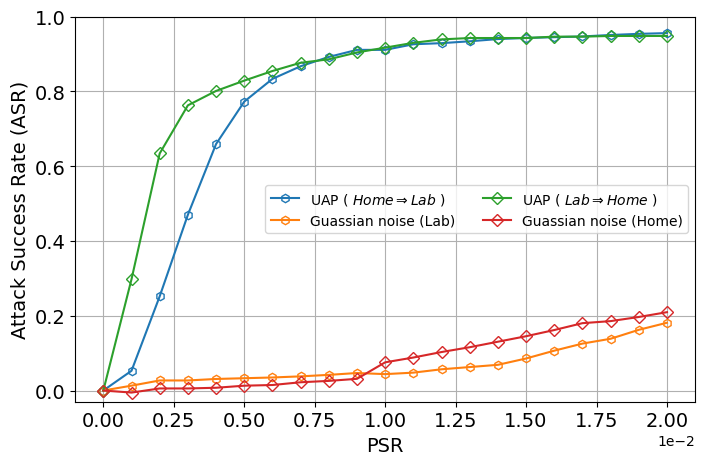

In [1]:
from Pub_plots import *
plot(
    		pdf_name = 'Cross_domain_atk_compare',
    		label_dict = {
    				'UAP_home_to_Lab': 'UAP ( $Home \Rightarrow Lab$ )',
    				'UAP_lab_to_Home': 'UAP ( $Lab  \Rightarrow Home$ )',
    				},
    		pltGuassian = 1,
    		UAP_home_to_Lab = 'UAP_signfi_atk_home_vic_lab_scale_1_more_psr.mat',
    		UAP_lab_to_Home = 'UAP_signfi_atk_lab_vic_home_scale_1_more_psr.mat',
    		# UAP_lab_to_lab = 'UAP_signfi_lab_scale_1.mat',
    		)